# Exploratory Data Analysis: Label Leakage

## Imports

In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Helper Functions

In [16]:
def normalize_text(text) -> str:
    """
    Normalize free text for robust phrase matching:
    - lowercase
    - punctuation -> spaces
    - collapse whitespace
    """
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_phrase(label: str) -> str:
    """
    Same behavior as your normalize_phrase:
    - remove leading numeric prefix like '1a', '2c', '3'
    - lowercase
    - punctuation -> spaces
    - collapse whitespace
    """
    label = str(label)
    label = re.sub(r"^\s*\d+[a-z]?\s*", "", label.strip(), flags=re.IGNORECASE)
    return normalize_text(label)


def phrase_in_text(phrase: str, text_norm: str) -> bool:
    """Match phrase as whole words (prevents partial matches)."""
    if not phrase:
        return False
    pattern = r"\b" + re.escape(phrase) + r"\b"
    return re.search(pattern, text_norm) is not None


def terms_for_label(canonical: str, aliases: list[str]) -> list[str]:
    """
    canonical + aliases, all normalized, unique.
    """
    terms = [canonical] + list(aliases or [])
    out = []
    for t in terms:
        t_norm = normalize_text(t)
        if t_norm and t_norm not in out:
            out.append(t_norm)
    return out


def any_label_match(text_norm: str, alias_dict_for_level: dict) -> bool:
    """
    True if ANY label (canonical or alias) from this level appears in text_norm.
    """
    for canonical, aliases in alias_dict_for_level.items():
        for term in terms_for_label(canonical, aliases):
            if phrase_in_text(term, text_norm):
                return True
    return False


def matched_labels_in_text(text_norm: str, alias_dict_for_level: dict) -> list[str]:
    """
    Returns a list of canonical labels (normalized) whose canonical OR alias matched.
    Used for labeled shortcut-risk (and can be used for unlabeled too if you want).
    """
    matches = []
    for canonical, aliases in alias_dict_for_level.items():
        canonical_norm = normalize_phrase(canonical)
        for term in terms_for_label(canonical, aliases):
            if phrase_in_text(term, text_norm):
                matches.append(canonical_norm)
                break

    # unique keep order
    seen, out = set(), []
    for m in matches:
        if m not in seen:
            out.append(m)
            seen.add(m)
    return out


def count_distinct_labels(text_norm: str, alias_dict_for_level: dict) -> int:
    """
    Count how many DISTINCT canonical labels match in text_norm.
    """
    return len(matched_labels_in_text(text_norm, alias_dict_for_level))


def classify_outcome(true_label_norm: str, matched_norm_labels: list[str]) -> str:
    """
    Outcomes:
      - exact:        true label matched AND it's the only match
      - ambiguous:    true label matched BUT other labels matched too
      - contradict:   at least one match BUT true label not among matches
      - inference:    no match BUT true label exists
      - missing_true: true label empty -> can't evaluate
    """
    true_label_norm = normalize_text(true_label_norm)
    matched_set = set(matched_norm_labels or [])

    if not true_label_norm:
        return "missing_true"
    if len(matched_set) == 0:
        return "inference"
    if true_label_norm in matched_set:
        return "exact" if len(matched_set) == 1 else "ambiguous"
    return "contradict"


def summarize_level(df_: pd.DataFrame, lvl: str) -> pd.Series:
    outcome_col = f"{lvl}_outcome"
    count_col   = f"{lvl}_alias_count"

    d = df_[df_[outcome_col] != "missing_true"].copy()
    if len(d) == 0:
        return pd.Series({
            "n": 0,
            "alias_coverage": 0.0,
            "exact_rate": 0.0,
            "ambiguity_rate": 0.0,
            "inference_only_rate": 0.0,
            "contradict_rate": 0.0,
            "avg_alias_count": 0.0,
        })

    return pd.Series({
        "n": len(d),
        "alias_coverage": (d[count_col] >= 1).mean(),
        "exact_rate": (d[outcome_col] == "exact").mean(),
        "ambiguity_rate": (d[outcome_col] == "ambiguous").mean(),
        "inference_only_rate": (d[outcome_col] == "inference").mean(),
        "contradict_rate": (d[outcome_col] == "contradict").mean(),
        "avg_alias_count": d[count_col].mean(),
    })


## Categories / Scenarios 

In [17]:
HIERARCHICAL_CATEGORIES = [
('1a MV (Mobile voice),', '2a Main product'),
('1a MV (Mobile voice),', '2a Smartwatch'),
('1a MV (Mobile voice),', '2a Datasharingcard'),
('1a MV (Mobile voice),', '2a Nummerportering'),
('1b MBB', '2b Main product'),
('1b MBB', '2b Datasharingcard'),
('1b MBB', '2b Router'),
('1b MBB', '2b Smart-sim'),
('1c TV', '2c COAX'),
('1c TV', '2c Fiber'),
('1c TV', '2c DSL'),
('1c TV', '2c OTT'),
('1d Broadband', '2d COAX'),
('1d Broadband', '2d Fiber'),
('1d Broadband', '2d DSL'),
('1e VoIP', '2e COAX'),
('1e VoIP', '2e Fiber'),
('1e VoIP', '2e DSL'),
('1e VoIP', '2e Fastnet på mobil'),
('1f PSTN', '2f Main product'),
('1f PSTN', '2f Add-on'),
('1g Self service', '2g Mit YouSee'),
('1g Self service', '2g YouSee Music'),
('1g Self service', '2g Mit Internet'),
('1g Self service', '2g YS-play'),
('1g Self service', '2g Webmail'),
('1 Misc incidents', '2 Other')
]

SCENARIOS = [
    "3 App",
    "3 Barring",
    "3 Billing/Invoices",
    "3 Change ownership",
    "3 Click & Collect",
    "3 CPR issues in Dawn",
    "3 Credit check",
    "3 CSRD",
    "3 Fraud",
    "3 Login issues",
    "3 Missing rights to access",
    "3 Mix-tv",
    "3 product status",
    "3 relocate",
    "3 onsite technician",
    "3 line technician",
    "3 Port in",
    "3 Port out",
    "3 payment method",
    "3 technical issues",
    "3 Order activation",
    "3 Order confirmation",
    "3 Performance issues",
    "3 Power of attorney",
    "3 Price and campaigns",
    "3 Proof of purchase",
    "3 Quote error",
    "3 Return/replace",
    "3 Shipment",
    "3 Sikkerhedspakke",
    "3 Stock",
    "3 Termination",
    "3 Third party",
    "3 Tickets",
    "3 User error",
    "3 Web"
]


## Aliases

In [18]:
ALIASES = {
    "level1": {
        "mbb": ["mobile broadband", "mobilt bredbånd", "mobile data"],
        "mv mobile voice": ["mv", "mobile voice"],
        "pstn": ["landline", "fixed line", "fastnet", "telefonstik"],
        "self service": ["selfservice", "account portal", "kundeportal"],
        "tv": ["television", "iptv"],
        "voip": ["ip telephony"],
    },
    "level2": {
        "add on": ["addon", "add-on"],
        "coax": ["cable", "docsis"],
        "datasharingcard": ["datasharing", "data sharing"],
        "dsl": ["adsl", "vdsl", "xdsl"],
        "fastnet på mobil": ["fastnet paa mobil", "fixed line on mobile"],
        "fiber": ["fibre", "ftth", "fiberline"],
        "mit internet": ["my internet", "internet portal"],
        "mit yousee": ["you see", "yousee", "mit yousee", "my yousee", "yousee app"],
        "nummerportering": ["number porting", "porting", "number transfer"],
        "ott": ["over the top", "over-the-top"],
        "router": ["modem", "gateway", "cpe"],
        "smart sim": ["smartsim", "sim", "esim", "e-sim", "physical sim"],
        "smartwatch": ["wearable", "watch"],
        "webmail": ["web mail"],
        "yousee music": ["music", "music app", "streaming music"],
        "ys play": ["yousee play"],
    },
    "level3": {
        "app": ["application", "mobile app"],
        "barring": ["barred", "blocked", "block"],
        "billing invoices": ["billing", "invoice", "invoices", "bill", "charges"],
        "change ownership": ["ownership change", "transfer ownership"],
        "click collect": ["click & collect", "click and collect"],
        "cpr issues in dawn": ["cpr issues", "dawn cpr", "issues in dawn"],
        "credit check": ["credit", "credit score"],
        "csrd": ["csrd"],
        "fraud": ["scam", "suspicious", "unauthorized"],
        "line technician": ["line tech"],
        "login issues": ["login", "log in", "sign in", "signin", "password", "cannot login"],
        "missing rights to access": ["missing rights", "no access", "cannot access", "access denied", "permission", "rights to access"],
        "mix tv": ["mix-tv", "mixtv"],
        "onsite technician": ["on site technician", "technician visit", "onsite visit"],
        "order activation": ["activate", "activation", "service start"],
        "order confirmation": ["confirmation", "confirm", "order received"],
        "payment method": ["credit card", "card", "direct debit", "bank"],
        "performance issues": ["performance", "slow", "latency", "speed", "buffering", "lag"],
        "port in": ["porting in", "incoming port"],
        "port out": ["porting out", "outgoing port"],
        "power of attorney": ["attorney", "poa", "authorization"],
        "price and campaigns": ["price", "pricing", "campaign", "campaigns", "discount"],
        "product status": ["status", "service status"],
        "proof of purchase": ["receipt", "invoice copy"],
        "quote error": ["quotation error", "quote failed"],
        "relocate": ["change address", "relocation", "move", "moving"],
        "return replace": ["return", "replace", "replacement", "rma"],
        "shipment": ["shipping", "delivery", "tracking"],
        "sikkerhedspakke": ["security package"],
        "stock": ["in stock", "out of stock", "availability"],
        "technical issues": ["technical", "not working", "broken", "down", "failure"],
        "termination": ["terminate", "cancel", "cancellation"],
        "third party": ["3rd party", "external partner"],
        "tickets": ["ticket", "case"],
        "user error": ["my mistake", "wrong input", "misconfiguration"],
        "web": ["website", "browser", "portal"],
    },
}

# Guardrail: fail loudly if ALIASES got overwritten to empty
assert all(len(ALIASES[lvl]) > 0 for lvl in ["level1","level2","level3"]), "ALIASES got overwritten/emptied!"


## Build vocabularies

In [19]:
level1_phrases = sorted({normalize_phrase(l1) for l1, _ in HIERARCHICAL_CATEGORIES})
level2_phrases = sorted({normalize_phrase(l2) for _, l2 in HIERARCHICAL_CATEGORIES})
level3_phrases = sorted({normalize_phrase(s) for s in SCENARIOS})

print("Level-1 phrases:", level1_phrases)
print("Level-2 phrases:", level2_phrases)
print("Level-3 phrases:", level3_phrases)

Level-1 phrases: ['broadband', 'mbb', 'misc incidents', 'mv mobile voice', 'pstn', 'self service', 'tv', 'voip']
Level-2 phrases: ['add on', 'coax', 'datasharingcard', 'dsl', 'fastnet på mobil', 'fiber', 'main product', 'mit internet', 'mit yousee', 'nummerportering', 'other', 'ott', 'router', 'smart sim', 'smartwatch', 'webmail', 'yousee music', 'ys play']
Level-3 phrases: ['app', 'barring', 'billing invoices', 'change ownership', 'click collect', 'cpr issues in dawn', 'credit check', 'csrd', 'fraud', 'line technician', 'login issues', 'missing rights to access', 'mix tv', 'onsite technician', 'order activation', 'order confirmation', 'payment method', 'performance issues', 'port in', 'port out', 'power of attorney', 'price and campaigns', 'product status', 'proof of purchase', 'quote error', 'relocate', 'return replace', 'shipment', 'sikkerhedspakke', 'stock', 'technical issues', 'termination', 'third party', 'tickets', 'user error', 'web']


## PART A — Unlabeled dataset: leakage EDA

### Load unlabeled data

- Load the unlabeled ticket dataset (no ground-truth labels per ticket).
- Standardize column names (lowercase + underscores) so later code is consistent.
- Drop columns with too many missing values and remove metadata fields that aren’t needed for text leakage analysis.

In [20]:
df = pd.read_csv(
    "/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/combined_data.csv"
)

df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
df = df.dropna(thresh=2300, axis=1)
df = df.drop(['updated', 'reporter','updated_by', 'status','reassignment_count','child_incidents','updated_by'], axis=1)

df.head()

,number,opened,reported_on_behalf_of,priority,service,title,description,work_notes,category,on_hold_reason,assignment_group,additional_comments,impact,urgency
0,INC0133168,2025-11-30 10:03:13,NaN,4 - Low,Broad- YouSeemail - Prod,Support - YouSee mail/Issue with Mit YouSee/Ca...,When the Customer tries to log in to his email...,NaN,Application,NaN,YouSee Mail Validation,NaN,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...
1,INC0133171,2025-11-30 10:20:22,NaN,4 - Low,TV-Video On Demand (VOD) - PROD,Support - TV/Video on demand/Streamer or Audio,Customer experiences that when they get up at ...,NaN,Application,NaN,TV-Video On Demand (VOD) – Validation,NaN,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...
2,INC0133177,2025-11-30 10:53:51,NaN,4 - Low,TV -Misc- Prod,Support - TV/Other/Bland Selv,"After the Customer got a new TV, the Customer'...",NaN,Application,NaN,TV-Misc – Validation,NaN,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...
3,INC0133167,2025-11-30 09:47:44,Incident Resolution Support,4 - Low,Dawn Agent UI - PROD,Support - Dawn/With Customer context/Other,It is listed as an ongoing change\n\nCategory:...,30-11-2025 11:40:19 - Casper Hjorth (Work note...,Application,NaN,Nuuday Front Desk,30-11-2025 11:40:19 - Casper Hjorth (Additiona...,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...
4,INC0133169,2025-11-30 10:05:27,Incident Resolution Support,4 - Low,Dawn Agent UI - PROD,Support - Dawn/With Customer context/Customer ...,"The Customer has changed address, applied CPR ...",NaN,Application,NaN,YAC-Resolution,30-11-2025 11:47:03 - Casper Hjorth (Additiona...,Minor - Errors affecting a group or a few cust...,Low - Total loss or degradation of a non-busin...


### Normalize fields
Create normalized versions of the raw text fields (title, description, assignment_group):
- lowercase everything
- replace punctuation with spaces
- collapse multiple spaces

This ensures phrase matching is robust (e.g., Login-issues, login issues, LOGIN issues become the same).

In [21]:
df["title_norm"] = df["title"].apply(normalize_text)
df["description_norm"] = df["description"].apply(normalize_text)
df["assignment_group_norm"] = df["assignment_group"].apply(normalize_text)

FIELDS = {
    "title": "title_norm",
    "description": "description_norm",
    "assignment_group": "assignment_group_norm",
}


### Leakage rates (%)

For each hierarchy level (level1/2/3) and each text field:

check: does any canonical label or alias appear anywhere in the text? (boolean)

Then compute mean() of that boolean column → this becomes the percentage of tickets with leakage for that level+field.

Output table answers: “How often could the label be guessed just because the label word appears?”

In [22]:
for level in ["level1", "level2", "level3"]:
    for field_name, col in FIELDS.items():
        df[f"{level.upper()}_in_{field_name}"] = df[col].apply(
            lambda x: any_label_match(x, ALIASES[level])
        )

leakage_summary = pd.DataFrame(
    {
        "title": [
            df["LEVEL1_in_title"].mean(),
            df["LEVEL2_in_title"].mean(),
            df["LEVEL3_in_title"].mean(),
        ],
        "description": [
            df["LEVEL1_in_description"].mean(),
            df["LEVEL2_in_description"].mean(),
            df["LEVEL3_in_description"].mean(),
        ],
        "assignment_group": [
            df["LEVEL1_in_assignment_group"].mean(),
            df["LEVEL2_in_assignment_group"].mean(),
            df["LEVEL3_in_assignment_group"].mean(),
        ],
    },
    index=["Level-1", "Level-2", "Level-3"],
)

print("Leakage rate (%) by level and field:")
print((leakage_summary * 100).round(2))


Leakage rate (%) by level and field:
         title  description  assignment_group
Level-1  12.93        23.58             10.95
Level-2  27.27        51.93             10.87
Level-3  40.40        85.65              0.15


**Level 1 (Top-level category)**  
Leakage is low across all fields (≈13% in titles, ≈24% in descriptions). Level-1 concepts are rarely stated explicitly and mostly need to be inferred from context.

**Level 2 (Product / subcategory)**  
Leakage is moderate, especially in descriptions (≈52%). Product names are often mentioned but not consistently, indicating partial but noisy surface-level signal.

**Level 3 (Issue type)**  
Leakage is very high in descriptions (≈86%) and substantial in titles (≈40%). Issue-related vocabulary is almost always present, but often overlapping and non-unique.

**Cross-field insight**  
Descriptions contain far more label vocabulary than titles. Assignment group contributes almost no leakage at any level, confirming it does not encode semantic labels.

**Key takeaway**  
High leakage at lower levels reflects dense and overlapping issue vocabulary rather than trivial label exposure. This creates ambiguity instead of enabling reliable shortcut learning.


### Distinct label counts (mean/median)

Instead of “any label appears?”, we now count:

how many different canonical labels match in a ticket’s title/description.

Compute mean + median across all tickets:

mean tells average number of label mentions

median tells what’s “typical” (often 0 or 1)

This quantifies ambiguity: many matches ⇒ the text contains cues for multiple labels.

In [23]:
for level in ["level1", "level2", "level3"]:
    df[f"{level.upper()}_labelcount_title"] = df["title_norm"].apply(
        lambda x: count_distinct_labels(x, ALIASES[level])
    )
    df[f"{level.upper()}_labelcount_description"] = df["description_norm"].apply(
        lambda x: count_distinct_labels(x, ALIASES[level])
    )

count_summary = pd.DataFrame(
    {
        "title_mean": [
            df["LEVEL1_labelcount_title"].mean(),
            df["LEVEL2_labelcount_title"].mean(),
            df["LEVEL3_labelcount_title"].mean(),
        ],
        "title_median": [
            df["LEVEL1_labelcount_title"].median(),
            df["LEVEL2_labelcount_title"].median(),
            df["LEVEL3_labelcount_title"].median(),
        ],
        "description_mean": [
            df["LEVEL1_labelcount_description"].mean(),
            df["LEVEL2_labelcount_description"].mean(),
            df["LEVEL3_labelcount_description"].mean(),
        ],
        "description_median": [
            df["LEVEL1_labelcount_description"].median(),
            df["LEVEL2_labelcount_description"].median(),
            df["LEVEL3_labelcount_description"].median(),
        ],
    },
    index=["Level-1", "Level-2", "Level-3"],
)

print("\nDistinct label matches per ticket (mean/median):")
print(count_summary.round(3))



Distinct label matches per ticket (mean/median):
         title_mean  title_median  description_mean  description_median
Level-1       0.130           0.0             0.242                 0.0
Level-2       0.350           0.0             0.767                 1.0
Level-3       0.456           0.0             1.893                 2.0


### Histograms

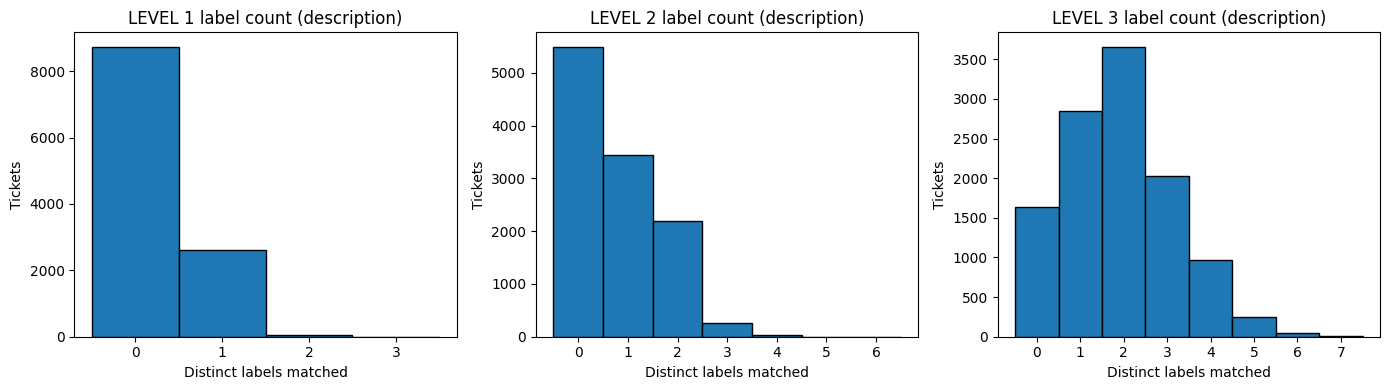

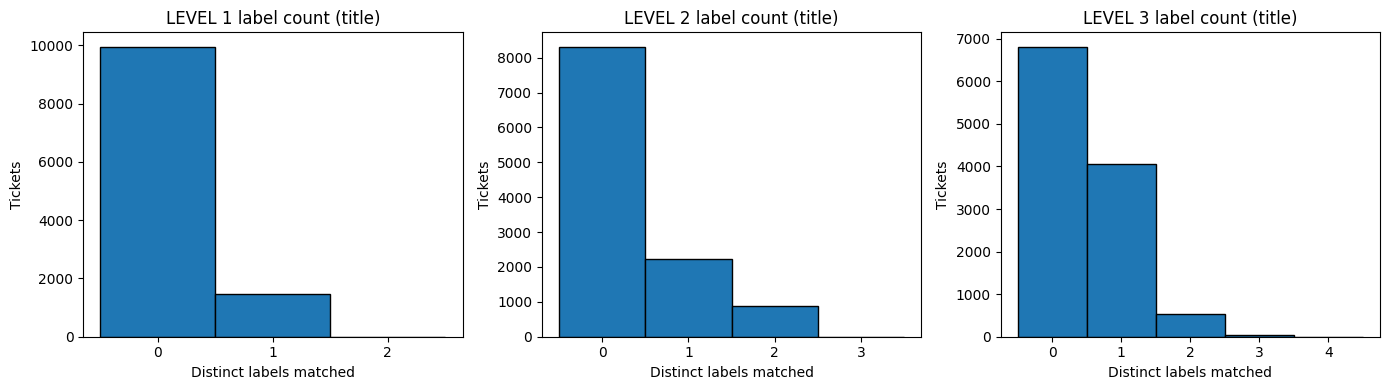

In [24]:
def plot_labelcount_histograms(df_, columns, titles, figsize=(14, 4)):
    plt.figure(figsize=figsize)
    for i, (col, title) in enumerate(zip(columns, titles), 1):
        data = df_[col].dropna().astype(int)
        max_val = data.max() if len(data) else 0
        bins = np.arange(0, max_val + 2) - 0.5

        plt.subplot(1, len(columns), i)
        plt.hist(data, bins=bins, edgecolor="black")
        plt.xticks(range(0, max_val + 1))
        plt.title(title)
        plt.xlabel("Distinct labels matched")
        plt.ylabel("Tickets")
        plt.grid(False)

    plt.tight_layout()
    plt.show()

plot_labelcount_histograms(
    df,
    columns=["LEVEL1_labelcount_description","LEVEL2_labelcount_description","LEVEL3_labelcount_description"],
    titles=["LEVEL 1 label count (description)","LEVEL 2 label count (description)","LEVEL 3 label count (description)"],
)

plot_labelcount_histograms(
    df,
    columns=["LEVEL1_labelcount_title","LEVEL2_labelcount_title","LEVEL3_labelcount_title"],
    titles=["LEVEL 1 label count (title)","LEVEL 2 label count (title)","LEVEL 3 label count (title)"],
)


**Level 1 (Top-level category)**  
Most tickets contain **zero or one** Level-1 label mention in both titles and descriptions. Multiple Level-1 matches are rare, indicating low ambiguity and little surface overlap at this level.

**Level 2 (Product / subcategory)**  
Descriptions frequently contain **one or two** Level-2 labels, with a noticeable tail toward higher counts. This reflects moderate ambiguity: multiple product terms are often mentioned in the same ticket. Titles remain sparser and less informative.

**Level 3 (Issue type)**  
Descriptions show the highest density, with many tickets matching **multiple (2–4+) issue labels**. This confirms heavy overlap of issue-related vocabulary. Titles show fewer matches, but still non-trivial overlap.

**Cross-field insight**  
Descriptions consistently contain more label mentions than titles. As label granularity increases (Level 1 → Level 3), the number of distinct labels per ticket increases sharply.

**Key takeaway**  
Lower levels exhibit high multi-label density, especially in descriptions, indicating substantial ambiguity. This supports the conclusion that surface text alone is insufficient and that semantic disambiguation is required, particularly for Level-3 classification.


## PART B — Labeled dataset: shortcut-risk (df_labeled)

### Load labeled dataset
Load a separate dataset that contains ground truth columns:

level1_true, level2_true, level3_true

Keep it separate from the unlabeled df so you don’t mix analyses.

In [26]:
LABELED_CSV = "/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/alsei/Thesis_IT_TicketClassification/data/merged_labeled_dec_2025_with_titles_and_levels.csv"

df_labeled = pd.read_csv(LABELED_CSV)
df_labeled.columns = [col.strip().lower().replace(" ", "_") for col in df_labeled.columns]

df_labeled.head()

,number,title,description,predicted_tags,source_file,level1_true,level2_true,level3_true
0,INC0133168,Support - YouSee mail/Issue with Mit YouSee/Ca...,When the Customer tries to log in to his email...,"(1g Self service, 2g Webmail), 3 Login issues",01-Dec-2025-result.xlsx,self service,webmail,login issues
1,INC0133168,Support - YouSee mail/Issue with Mit YouSee/Ca...,When the Customer tries to log in to his email...,"(1g Self service, 2g Webmail), 3 Login issues",01-Dec-2025-result.xlsx,self service,webmail,login issues
2,INC0133168,Support - YouSee mail/Issue with Mit YouSee/Ca...,When the Customer tries to log in to his email...,"(1g Self service, 2g Webmail), 3 Login issues",01-Dec-2025-result.xlsx,self service,webmail,login issues
3,INC0133171,Support - TV/Video on demand/Streamer or Audio,Customer experiences that when they get up at ...,"(1c TV, 2c OTT), 3 technical issues",01-Dec-2025-result.xlsx,tv,ott,technical issues
4,INC0133171,Support - TV/Video on demand/Streamer or Audio,Customer experiences that when they get up at ...,"(1c TV, 2c OTT), 3 technical issues",01-Dec-2025-result.xlsx,tv,ott,technical issues


### Normalize labeled text + true labels

Create one combined normalized text field (text_norm) = normalized(title) + normalized(description).

Normalize the true labels as well (same cleaning as phrases):

- removes prefixes like 3, 2a, etc.

- lowercases + removes punctuation

Goal: make true label strings comparable to matched alias strings.

In [27]:
COL_NUMBER = "number"
COL_TITLE  = "title"
COL_DESC   = "description"
COL_L1     = "level1_true"
COL_L2     = "level2_true"
COL_L3     = "level3_true"

for c in [COL_TITLE, COL_DESC]:
    if c not in df_labeled.columns:
        df_labeled[c] = ""

df_labeled["text_norm"] = (
    df_labeled[COL_TITLE].apply(normalize_text)
    + " "
    + df_labeled[COL_DESC].apply(normalize_text)
).str.strip()

for c in [COL_L1, COL_L2, COL_L3]:
    if c in df_labeled.columns:
        df_labeled[c] = df_labeled[c].apply(normalize_phrase)
    else:
        df_labeled[c] = ""


### Match aliases in text + compare vs true label

For each level:

levelX_alias_matches: list of canonical labels whose vocabulary (canonical name or alias) appears in text_norm

levelX_alias_count: how many distinct canonical labels were matched

levelX_outcome: compare matched labels vs true label:

- exact: true label appears AND it’s the only match

- ambiguous: true label appears BUT other labels also appear

- contradict: some labels appear BUT not the true one

- inference: no label vocabulary appears, so model must infer from other words

- missing_true: no true label available (excluded from evaluation)

In [28]:
LEVEL_TO_TRUECOL = {"level1": COL_L1, "level2": COL_L2, "level3": COL_L3}

for lvl, true_col in LEVEL_TO_TRUECOL.items():
    df_labeled[f"{lvl}_alias_matches"] = df_labeled["text_norm"].apply(
        lambda t: matched_labels_in_text(t, ALIASES[lvl])
    )
    df_labeled[f"{lvl}_alias_count"] = df_labeled[f"{lvl}_alias_matches"].apply(len)
    df_labeled[f"{lvl}_outcome"] = df_labeled.apply(
        lambda r: classify_outcome(r[true_col], r[f"{lvl}_alias_matches"]),
        axis=1
    )


### Shortcut-risk summary table

Aggregate outcomes into interpretable metrics per level:

- alias_coverage: % tickets with ≥1 alias match

- exact_rate: % tickets where the true label is directly “revealed” in text

- ambiguity_rate: % tickets where the true label is present but mixed with others

- inference_only_rate: % tickets with no vocabulary match (needs real reasoning)

- contradict_rate: % tickets where vocabulary suggests wrong labels

- avg_alias_count: average number of matched canonical labels per ticket

This quantifies shortcut learning risk and how misleading the text cues are.

In [29]:
summary_df = pd.DataFrame(
    {lvl.upper(): summarize_level(df_labeled, lvl) for lvl in ["level1","level2","level3"]}
).T

summary_pretty = summary_df.copy()
for c in ["alias_coverage","exact_rate","ambiguity_rate","inference_only_rate","contradict_rate"]:
    summary_pretty[c] = (summary_pretty[c] * 100).round(2)
summary_pretty["avg_alias_count"] = summary_pretty["avg_alias_count"].round(2)

print("\nShortcut-risk summary (per level):")
print(summary_pretty)



Shortcut-risk summary (per level):
              n  alias_coverage  exact_rate  ambiguity_rate  \
LEVEL1  23659.0           25.42       13.72            0.42   
LEVEL2  23659.0           54.42       21.14           20.10   
LEVEL3  23659.0           85.96        4.81           31.79   

        inference_only_rate  contradict_rate  avg_alias_count  
LEVEL1                74.58            11.29             0.26  
LEVEL2                45.58            13.18             0.82  
LEVEL3                14.04            49.37             1.92  


### Conclusion

LEVEL 1 (Top-level category):

- Only ~25% of tickets explicitly mention any Level-1 label or alias.
- Just ~14% of tickets literally contain the correct Level-1 label in the text.
- In ~75% of cases, the Level-1 label cannot be recovered from vocabulary alone → the model must infer it from context.
- When aliases do appear, they are usually clean (avg < 0.3 matches, ambiguity almost zero).

--> Level-1 classification largely requires semantic understanding, not keyword spotting.
This level is safe for distillation and training.

---

LEVEL 2 (Product / subcategory):
- In more than half the tickets, Level-2 labels or aliases appear explicitly.
- Only ~21% are trivial “label-is-in-the-text” cases.
- Ambiguity is substantial: ~20% of tickets mention multiple Level-2 labels.
- Nearly 46% of tickets still require inference.
- Alias presence is often noisy (almost 1 label per ticket on average).

--> There is partial leakage, but also significant ambiguity.
A student model cannot rely purely on keywords without being wrong often. This is a realistic but challenging supervision signal.

---

LEVEL 3 (Issue / problem type)
- Almost 86% of tickets mention some Level-3 issue vocabulary.
- But only ~5% mention the correct label unambiguously.
- On average, ~2 different issue labels appear per ticket.
- Nearly 50% of cases are contradictory: the text contains other issue labels but not the true one.
- Pure keyword-based labeling would be actively misleading.

--> Very high shortcut noise (but not trivial leakage)

Important nuance:
This is not “easy leakage” --> This is semantic overload:
- tickets describe symptoms, not the final classification
- many issue terms co-occur

This level requires reasoning and disambiguation, not pattern matching.

### Sanity-check examples (level 3)

Print a few exact cases to confirm matches look correct.

Print a few inference cases to confirm those truly contain no alias/label vocabulary.

This is a qualitative verification that the metrics are meaningful.

In [30]:
cols_show = [c for c in [COL_NUMBER, COL_TITLE, COL_DESC, COL_L3, "level3_alias_matches", "level3_outcome"] if c in df_labeled.columns]

print("\nLEVEL3 exact examples:")
print(df_labeled[df_labeled["level3_outcome"]=="exact"][cols_show].head(5).to_string(index=False))

print("\nLEVEL3 inference examples:")
print(df_labeled[df_labeled["level3_outcome"]=="inference"][cols_show].head(5).to_string(index=False))



LEVEL3 exact examples:
    number                                                                                 title                                                                                                                                                                                                                                                                                                                                                                                                                                                                  description              level3_true       level3_alias_matches level3_outcome
INC0133192 Support - YouSee mail/Issue with Mit YouSee/Can't access mail (due to incorrect user)                                                                                                                                                           The customer's email is not linked to their account, and they are also not allowed to link it to the